In [4]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
#loading the messy data
df = pd.read_csv('ebimo.csv')
df

,OrderID,CustomerName,Region,ShipMode,OrderDate,ShipDate,DeliveryDays,Weight(kg),Distance(km),ShippingCost,Status
0,1001,Alice Johnson,North,Express,1/3/2024,1/5/2024,2,5.2,120,45,Delivered
1,1002,Bob Smith,South,Standard,1/4/2024,1/8/2024,4,12.0,340,30,Delivered
2,1003,Carol White,East,Express,1/5/2024,1/7/2024,2,3.1,90,40,Delayed
3,1004,David Brown,West,Economy,1/6/2024,1/12/2024,6,20.5,500,20,Delivered
4,1005,Eva Green,North,Standard,1/7/2024,1/11/2024,4,8.0,210,28,Delayed
5,1006,Frank Black,South,Express,1/8/2024,1/10/2024,2,6.5,150,43,Delivered
6,1007,Grace Lee,East,Economy,1/9/2024,1/15/2024,6,15.0,420,18,Lost
7,1008,Henry Adams,West,Standard,1/10/2024,1/14/2024,4,9.2,270,31,Delivered
8,1009,Irene Clark,North,Express,1/11/2024,1/13/2024,2,4.0,100,42,Delivered
9,1010,James Hall,South,Economy,1/12/2024,1/18/2024,6,22.0,600,17,Delayed


# 2. Initial inspection (ALWAYS do this first!)

In [6]:
print(df.head())

   OrderID   CustomerName Region  ShipMode OrderDate   ShipDate  DeliveryDays  \
0     1001  Alice Johnson  North   Express  1/3/2024   1/5/2024             2   
1     1002      Bob Smith  South  Standard  1/4/2024   1/8/2024             4   
2     1003    Carol White   East   Express  1/5/2024   1/7/2024             2   
3     1004    David Brown   West   Economy  1/6/2024  1/12/2024             6   
4     1005      Eva Green  North  Standard  1/7/2024  1/11/2024             4   

   Weight(kg)  Distance(km)  ShippingCost     Status  
0         5.2           120            45  Delivered  
1        12.0           340            30  Delivered  
2         3.1            90            40    Delayed  
3        20.5           500            20  Delivered  
4         8.0           210            28    Delayed  


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OrderID       20 non-null     int64  
 1   CustomerName  20 non-null     str    
 2   Region        20 non-null     str    
 3   ShipMode      20 non-null     str    
 4   OrderDate     20 non-null     str    
 5   ShipDate      20 non-null     str    
 6   DeliveryDays  20 non-null     int64  
 7   Weight(kg)    20 non-null     float64
 8   Distance(km)  20 non-null     int64  
 9   ShippingCost  20 non-null     int64  
 10  Status        20 non-null     str    
dtypes: float64(1), int64(4), str(6)
memory usage: 1.8 KB
None


In [8]:
print(df.isnull().sum())

OrderID         0
CustomerName    0
Region          0
ShipMode        0
OrderDate       0
ShipDate        0
DeliveryDays    0
Weight(kg)      0
Distance(km)    0
ShippingCost    0
Status          0
dtype: int64


In [9]:
x = df.iloc[:, [2, 3, 6, 7, 8, 9]].values
y = df.iloc[:, -1].values

In [10]:
print(x)

[['North' 'Express' 2 5.2 120 45]
 ['South' 'Standard' 4 12.0 340 30]
 ['East' 'Express' 2 3.1 90 40]
 ['West' 'Economy' 6 20.5 500 20]
 ['North' 'Standard' 4 8.0 210 28]
 ['South' 'Express' 2 6.5 150 43]
 ['East' 'Economy' 6 15.0 420 18]
 ['West' 'Standard' 4 9.2 270 31]
 ['North' 'Express' 2 4.0 100 42]
 ['South' 'Economy' 6 22.0 600 17]
 ['East' 'Standard' 4 7.5 190 29]
 ['West' 'Express' 2 5.0 130 44]
 ['North' 'Economy' 6 18.0 480 19]
 ['South' 'Standard' 4 11.0 310 32]
 ['East' 'Express' 2 3.8 85 41]
 ['West' 'Economy' 6 25.0 650 16]
 ['North' 'Standard' 4 9.8 230 30]
 ['South' 'Express' 2 6.0 140 43]
 ['East' 'Economy' 6 19.5 520 18]
 ['West' 'Standard' 4 8.5 200 29]]


In [11]:
print (y)

<StringArray>
['Delivered', 'Delivered',   'Delayed', 'Delivered',   'Delayed', 'Delivered',
      'Lost', 'Delivered', 'Delivered',   'Delayed', 'Delivered', 'Delivered',
   'Delayed', 'Delivered', 'Delivered',      'Lost', 'Delivered',   'Delayed',
 'Delivered', 'Delivered']
Length: 20, dtype: str


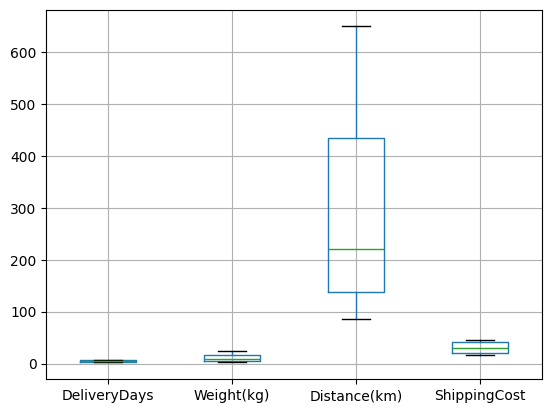

In [12]:
df.boxplot(column=['DeliveryDays', 'Weight(kg)', 'Distance(km)', 'ShippingCost'])
plt.show()

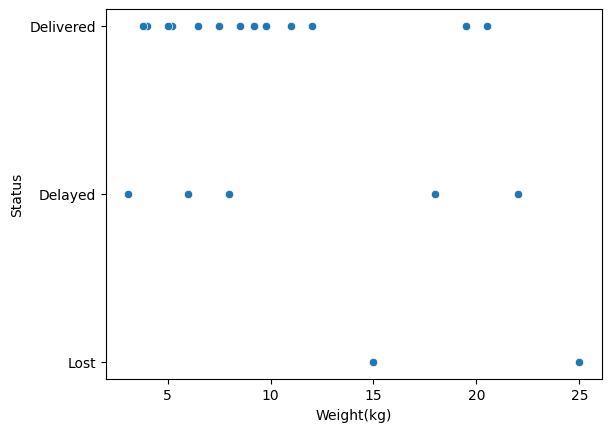

In [13]:
sns.scatterplot(x='Weight(kg)', y='Status', data=df)
plt.show()

In [14]:
df.isnull()

,OrderID,CustomerName,Region,ShipMode,OrderDate,ShipDate,DeliveryDays,Weight(kg),Distance(km),ShippingCost,Status
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [0, 1])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [16]:
print (x)

[[0.0 1.0 0.0 0.0 0.0 1.0 0.0 2 5.2 120 45]
 [0.0 0.0 1.0 0.0 0.0 0.0 1.0 4 12.0 340 30]
 [1.0 0.0 0.0 0.0 0.0 1.0 0.0 2 3.1 90 40]
 [0.0 0.0 0.0 1.0 1.0 0.0 0.0 6 20.5 500 20]
 [0.0 1.0 0.0 0.0 0.0 0.0 1.0 4 8.0 210 28]
 [0.0 0.0 1.0 0.0 0.0 1.0 0.0 2 6.5 150 43]
 [1.0 0.0 0.0 0.0 1.0 0.0 0.0 6 15.0 420 18]
 [0.0 0.0 0.0 1.0 0.0 0.0 1.0 4 9.2 270 31]
 [0.0 1.0 0.0 0.0 0.0 1.0 0.0 2 4.0 100 42]
 [0.0 0.0 1.0 0.0 1.0 0.0 0.0 6 22.0 600 17]
 [1.0 0.0 0.0 0.0 0.0 0.0 1.0 4 7.5 190 29]
 [0.0 0.0 0.0 1.0 0.0 1.0 0.0 2 5.0 130 44]
 [0.0 1.0 0.0 0.0 1.0 0.0 0.0 6 18.0 480 19]
 [0.0 0.0 1.0 0.0 0.0 0.0 1.0 4 11.0 310 32]
 [1.0 0.0 0.0 0.0 0.0 1.0 0.0 2 3.8 85 41]
 [0.0 0.0 0.0 1.0 1.0 0.0 0.0 6 25.0 650 16]
 [0.0 1.0 0.0 0.0 0.0 0.0 1.0 4 9.8 230 30]
 [0.0 0.0 1.0 0.0 0.0 1.0 0.0 2 6.0 140 43]
 [1.0 0.0 0.0 0.0 1.0 0.0 0.0 6 19.5 520 18]
 [0.0 0.0 0.0 1.0 0.0 0.0 1.0 4 8.5 200 29]]


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y = le.fit_transform(y)
print(Y)

[1 1 0 1 0 1 2 1 1 0 1 1 0 1 1 2 1 0 1 1]


In [18]:
from sklearn.model_selection import train_test_split
x_train, X_test, y_train, y_test = train_test_split(x, Y, test_size=0.2, random_state=24)

In [19]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
y_pred = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [22]:
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")

MAE: 0.9051374956749352
MSE: 1.7857165905495764
R2: -2.571433181099153
